In [6]:
import os
import sqlite3
import numpy as np
import pandas as pd

project_folder = 'C:/Users/nikol/Desktop/Athens_Airbnb_Project/'
file_path = os.path.join(project_folder, 'listings.csv.gz')

if not os.path.exists(file_path):
  file_path = os.path.join(project_folder, 'listings.csv')

df_raw = pd.read_csv(file_path, low_memory=False)
print(
    f' Raw Athens dataset loaded: {df_raw.shape[0]} listings and'
    f' {df_raw.shape[1]} columns.'
)

df_raw['price_clean'] = (
    df_raw['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)
df_raw['price_clean'] = pd.to_numeric(df_raw['price_clean'], errors='coerce')

# Split into 3 Normalized Relational Tables for SQLite (hosts, listings, reviews_occupancy)
hosts_df = df_raw[[
    'host_id',
    'host_is_superhost',
    'calculated_host_listings_count',
    'host_identity_verified',
]].drop_duplicates(subset=['host_id'])

listings_df = df_raw[[
    'id',
    'host_id',
    'neighbourhood_cleansed',
    'latitude',
    'longitude',
    'room_type',
    'accommodates',
    'bedrooms',
    'beds',
    'price_clean',
    'instant_bookable',
    'minimum_nights',
]].rename(columns={'id': 'listing_id', 'price_clean': 'price'})

reviews_df = df_raw[[
    'id',
    'number_of_reviews',
    'number_of_reviews_ltm',
    'review_scores_rating',
    'review_scores_location',
    'availability_365',
    'estimated_occupancy_l365d',
]].rename(columns={'id': 'listing_id'})

# Load tables into SQLite database
db_path = os.path.join(project_folder, 'athens_airbnb.db')
conn = sqlite3.connect(db_path)

hosts_df.to_sql('hosts', conn, if_exists='replace', index=False)
listings_df.to_sql('listings', conn, if_exists='replace', index=False)
reviews_df.to_sql('reviews_occupancy', conn, if_exists='replace', index=False)

print(
    " Relational SQLite Database 'athens_airbnb.db' created with 3 tables:"
    ' hosts, listings, reviews_occupancy!'
)

 Raw Athens dataset loaded: 14337 listings and 90 columns.
 Relational SQLite Database 'athens_airbnb.db' created with 3 tables: hosts, listings, reviews_occupancy!


In [7]:
sql_feature_query = """
SELECT 
    l.listing_id,
    l.host_id,
    l.neighbourhood_cleansed AS neighborhood_fe,
    l.latitude,
    l.longitude,
    l.price,
    l.accommodates,
    COALESCE(l.bedrooms, 1.0) AS bedrooms,
    COALESCE(l.beds, 1.0) AS beds,
    
    -- Binary (1/0) Property & Host Indicators
    CASE WHEN l.room_type = 'Entire home/apt' THEN 1 ELSE 0 END AS entire_home,
    CASE WHEN l.instant_bookable = 't' THEN 1 ELSE 0 END AS instant_book,
    CASE WHEN h.host_is_superhost = 't' THEN 1 ELSE 0 END AS superhost,
    CASE WHEN h.calculated_host_listings_count > 2 THEN 1 ELSE 0 END AS commercial_host,
    h.calculated_host_listings_count AS host_listings_count,
    
    -- Demand, Occupancy & Quality Metrics
    r.number_of_reviews,
    r.number_of_reviews_ltm,
    r.review_scores_rating,
    r.estimated_occupancy_l365d AS est_occupancy_days,
    CASE WHEN r.estimated_occupancy_l365d >= 180 THEN 1 ELSE 0 END AS high_occupancy

FROM listings l
INNER JOIN hosts h ON l.host_id = h.host_id
INNER JOIN reviews_occupancy r ON l.listing_id = r.listing_id
WHERE l.price IS NOT NULL 
  AND l.price BETWEEN 15 AND 1000
  AND r.number_of_reviews > 0
  AND r.review_scores_rating IS NOT NULL;
"""

df_athens = pd.read_sql_query(sql_feature_query, conn)

# Calculate distance (in km) from the Acropolis 
acropolis_lat, acropolis_lon = 37.9715, 23.7257
lat_km = (df_athens['latitude'] - acropolis_lat) * 111.0
lon_km = (df_athens['longitude'] - acropolis_lon) * 111.0 * np.cos(np.radians(acropolis_lat))
df_athens['dist_acropolis_km'] = np.sqrt(lat_km**2 + lon_km**2)

# Create natural log of nightly price for the OLS model
df_athens['log_price'] = np.log(df_athens['price'])

print(f" Econometric Sample Constructed: {df_athens.shape[0]} active reviewed Athens listings.")
display(df_athens.head())

 Econometric Sample Constructed: 12297 active reviewed Athens listings.


,listing_id,host_id,neighborhood_fe,latitude,longitude,price,accommodates,bedrooms,beds,entire_home,...,superhost,commercial_host,host_listings_count,number_of_reviews,number_of_reviews_ltm,review_scores_rating,est_occupancy_days,high_occupancy,dist_acropolis_km,log_price
0,1688956109252030943,523539923,ΠΛΑΤΕΙΑ ΑΜΕΡΙΚΗΣ,38.002810,23.730280,50.21,2,1.0,1.0,0,...,0,1,3,1,1,3.00,6,0,3.498441,3.916214
1,49726566,155617522,ΠΑΓΚΡΑΤΙ,37.972672,23.744352,45.50,2,1.0,1.0,1,...,1,1,21,262,53,4.69,255,1,1.637311,3.817712
2,1672568196175885413,720426710,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.985516,23.726697,99.00,2,1.0,1.0,1,...,0,1,52,3,3,4.33,18,0,1.558264,4.595120
3,1297763974395250471,206967394,ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ,37.994811,23.725550,118.60,6,3.0,4.0,1,...,1,0,2,1,1,5.00,6,0,2.587543,4.775756
4,1321821606402226863,269957527,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.985900,23.729950,500.00,5,2.0,4.0,1,...,1,1,3,1,0,5.00,0,0,1.641092,6.214608


In [8]:
# Summary Statistics of the Athens Airbnb Market
summary_vars = [
    'price',
    'dist_acropolis_km',
    'accommodates',
    'bedrooms',
    'entire_home',
    'superhost',
    'commercial_host',
    'review_scores_rating',
    'number_of_reviews',
    'high_occupancy',
]

athens_summary = pd.DataFrame({
    'Mean': df_athens[summary_vars].mean().round(2),
    'Std Dev': df_athens[summary_vars].std().round(2),
    'Median': df_athens[summary_vars].median().round(2),
    'Min': df_athens[summary_vars].min().round(2),
    'Max': df_athens[summary_vars].max().round(2),
})

print("=== Summary Statistics: Athens Airbnb Market (N = 12,297 Listings) ===")
display(athens_summary)

print("\n--- Market Structure Highlights ---")
print(
    f"Average Nightly Price: €{df_athens['price'].mean():.2f} (Median:"
    f" €{df_athens['price'].median():.2f})"
)
print(f"Entire Homes / Apartments: {df_athens['entire_home'].mean() * 100:.1f}%")
print(
    'Commercial Multi-Listing Hosts (>2 properties):'
    f" {df_athens['commercial_host'].mean() * 100:.1f}%"
)
print(f"Superhosts: {df_athens['superhost'].mean() * 100:.1f}%")
print(
    f"Average Distance to Acropolis: {df_athens['dist_acropolis_km'].mean():.2f}"
    ' km'
)

=== Summary Statistics: Athens Airbnb Market (N = 12,297 Listings) ===


,Mean,Std Dev,Median,Min,Max
price,128.12,91.61,103.00,17.57,1000.00
dist_acropolis_km,1.72,1.11,1.48,0.10,6.77
accommodates,3.80,1.98,4.00,1.00,16.00
bedrooms,1.47,0.79,1.00,1.00,12.00
entire_home,0.95,0.23,1.00,0.00,1.00
superhost,0.53,0.50,1.00,0.00,1.00
commercial_host,0.62,0.49,1.00,0.00,1.00
review_scores_rating,4.77,0.37,4.87,1.00,5.00
number_of_reviews,74.25,113.14,28.00,1.00,1093.00
high_occupancy,0.20,0.40,0.00,0.00,1.00



--- Market Structure Highlights ---
Average Nightly Price: €128.12 (Median: €103.00)
Entire Homes / Apartments: 94.5%
Commercial Multi-Listing Hosts (>2 properties): 62.0%
Superhosts: 52.9%
Average Distance to Acropolis: 1.72 km


In [10]:
import statsmodels.formula.api as smf

# Model 1: Semi-Logarithmic Hedonic Pricing Model
hedonic_formula = """log_price ~ dist_acropolis_km + accommodates + bedrooms + entire_home + 
                     superhost + commercial_host + review_scores_rating + instant_book + C(neighborhood_fe)"""

hedonic_model = smf.ols(formula=hedonic_formula, data=df_athens).fit(cov_type='HC1')

# Model 2: Linear Probability Model for High Occupancy (>= 180 days/year)
occupancy_formula = """high_occupancy ~ log_price + dist_acropolis_km + accommodates + bedrooms + entire_home + 
                       superhost + commercial_host + review_scores_rating + instant_book + C(neighborhood_fe)"""

lpm_occupancy = smf.ols(formula=occupancy_formula, data=df_athens).fit(cov_type='HC1')

core_vars = [
    'dist_acropolis_km', 
    'accommodates', 
    'bedrooms', 
    'entire_home', 
    'superhost', 
    'commercial_host', 
    'review_scores_rating', 
    'instant_book'
]

results_table = pd.DataFrame({
    "Hedonic Coef (Log Price)": hedonic_model.params[core_vars].round(4),
    "Hedonic Robust SE": hedonic_model.bse[core_vars].round(4),
    "Hedonic p-value": hedonic_model.pvalues[core_vars].round(4),
    "Occupancy Coef (LPM)": lpm_occupancy.params[core_vars].round(4),
    "Occupancy Robust SE": lpm_occupancy.bse[core_vars].round(4),
    "Occupancy p-value": lpm_occupancy.pvalues[core_vars].round(4)
})

print("=== Econometric Results: Athens Hedonic Pricing & High-Occupancy LPM ===")
display(results_table)

print(f"\nPrice Impact in Occupancy Model: log_price Coef = {lpm_occupancy.params['log_price']:.4f} (p = {lpm_occupancy.pvalues['log_price']:.4f})")
print(f"Hedonic Pricing Model R-squared: {hedonic_model.rsquared:.4f} (Adjusted R-squared: {hedonic_model.rsquared_adj:.4f})")
print(f"High Occupancy LPM R-squared: {lpm_occupancy.rsquared:.4f}")

=== Econometric Results: Athens Hedonic Pricing & High-Occupancy LPM ===


,Hedonic Coef (Log Price),Hedonic Robust SE,Hedonic p-value,Occupancy Coef (LPM),Occupancy Robust SE,Occupancy p-value
dist_acropolis_km,-0.2548,0.0110,0.0000,-0.1264,0.0113,0.0000
accommodates,0.0718,0.0044,0.0000,-0.0008,0.0029,0.7711
bedrooms,0.1942,0.0126,0.0000,0.0347,0.0070,0.0000
entire_home,0.2837,0.0216,0.0000,0.0869,0.0146,0.0000
superhost,0.0273,0.0069,0.0001,0.1658,0.0069,0.0000
commercial_host,0.0491,0.0069,0.0000,-0.0179,0.0075,0.0167
review_scores_rating,0.1285,0.0117,0.0000,0.0738,0.0052,0.0000
instant_book,0.0000,0.0000,NaN,0.0000,0.0000,NaN



Price Impact in Occupancy Model: log_price Coef = -0.1588 (p = 0.0000)
Hedonic Pricing Model R-squared: 0.5153 (Adjusted R-squared: 0.5133)
High Occupancy LPM R-squared: 0.1151


In [12]:
# SQL Window Function Ranking of Athens Neighborhoods
neighborhood_rank_query = """
WITH neighborhood_stats AS (
    SELECT 
        l.neighbourhood_cleansed AS neighborhood,
        COUNT(l.listing_id) AS total_listings,
        ROUND(AVG(l.price), 2) AS avg_nightly_price,
        ROUND(AVG(CASE WHEN l.room_type = 'Entire home/apt' THEN 1.0 ELSE 0.0 END) * 100, 1) AS pct_entire_homes,
        ROUND(AVG(CASE WHEN h.calculated_host_listings_count > 2 THEN 1.0 ELSE 0.0 END) * 100, 1) AS pct_commercial_hosts,
        ROUND(AVG(r.review_scores_rating), 2) AS avg_rating,
        ROUND(AVG(r.estimated_occupancy_l365d), 1) AS avg_occupancy_days,
        ROUND(SUM(l.price * r.estimated_occupancy_l365d), 2) AS est_total_annual_revenue
    FROM listings l
    INNER JOIN hosts h ON l.host_id = h.host_id
    INNER JOIN reviews_occupancy r ON l.listing_id = r.listing_id
    WHERE l.price BETWEEN 15 AND 1000
      AND r.number_of_reviews > 0
    GROUP BY l.neighbourhood_cleansed
    HAVING COUNT(l.listing_id) >= 100
)
SELECT 
    RANK() OVER (ORDER BY est_total_annual_revenue DESC) AS revenue_rank,
    neighborhood,
    total_listings,
    avg_nightly_price,
    avg_occupancy_days,
    pct_commercial_hosts,
    pct_entire_homes,
    est_total_annual_revenue
FROM neighborhood_stats
ORDER BY revenue_rank ASC
LIMIT 12;
"""

df_neighborhood_rank = pd.read_sql_query(neighborhood_rank_query, conn)
print("=== Top 12 Athens Neighborhoods by Estimated Annual Revenue (SQL Window Function) ===")
display(df_neighborhood_rank)

=== Top 12 Athens Neighborhoods by Estimated Annual Revenue (SQL Window Function) ===


,revenue_rank,neighborhood,total_listings,avg_nightly_price,avg_occupancy_days,pct_commercial_hosts,pct_entire_homes,est_total_annual_revenue
0,1,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,2510,152.49,90.4,79.2,93.4,33278083.09
1,2,ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ,1195,154.93,110.7,65.2,98.6,19908412.99
2,3,ΝΕΟΣ ΚΟΣΜΟΣ,918,121.00,95.7,56.8,98.4,10285014.84
3,4,ΑΚΡΟΠΟΛΗ,380,176.42,112.3,55.8,98.4,7828345.62
4,5,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,866,112.45,77.2,60.5,94.9,7074133.72
5,6,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,802,95.08,96.3,67.7,86.5,6489714.11
6,7,ΘΗΣΕΙΟ,380,147.62,106.0,60.8,94.5,5707955.91
7,8,ΚΕΡΑΜΕΙΚΟΣ,384,139.57,111.8,70.1,93.2,5115757.33
8,9,ΚΟΛΩΝΑΚΙ,389,164.02,67.0,63.8,95.6,4267426.92
9,10,ΠΑΓΚΡΑΤΙ,482,114.62,70.9,48.3,96.9,3826808.73


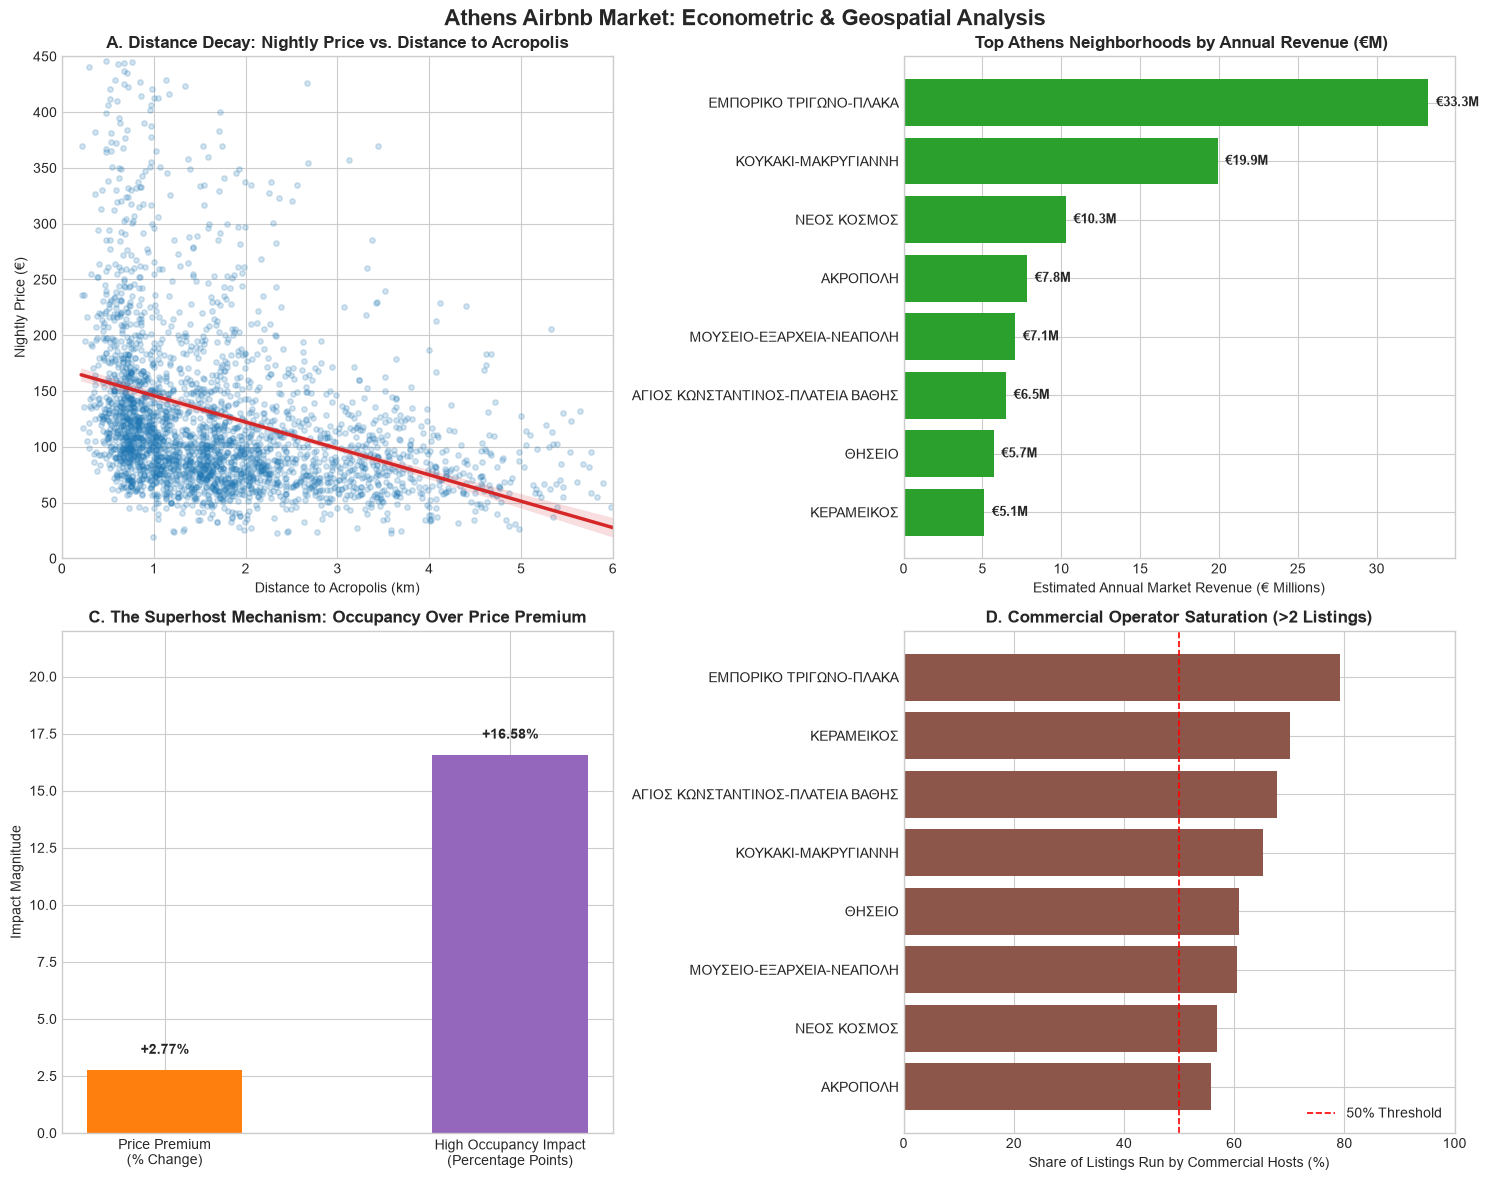

 Figure saved successfully as: athens_econometric_findings.png


In [13]:
# Visualizations & Figure Export
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Athens Airbnb Market: Econometric & Geospatial Analysis', fontsize=16, fontweight='bold', y=0.98)

sns.regplot(
    data=df_athens.sample(n=3000, random_state=42), 
    x='dist_acropolis_km', y='price', 
    ax=axes[0, 0], color='#1f77b4',
    scatter_kws={'alpha': 0.2, 's': 15}, 
    line_kws={'color': '#d62728', 'linewidth': 2.5}
)
axes[0, 0].set_title('A. Distance Decay: Nightly Price vs. Distance to Acropolis', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Distance to Acropolis (km)')
axes[0, 0].set_ylabel('Nightly Price (€)')
axes[0, 0].set_ylim(0, 450)
axes[0, 0].set_xlim(0, 6)

# Top 8 Neighborhoods by Annual Revenue
top_neigh = df_neighborhood_rank.head(8).sort_values('est_total_annual_revenue', ascending=True)
bars = axes[0, 1].barh(top_neigh['neighborhood'], top_neigh['est_total_annual_revenue'] / 1e6, color='#2ca02c')
axes[0, 1].set_title(' Top Athens Neighborhoods by Annual Revenue (€M)', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Estimated Annual Market Revenue (€ Millions)')
for bar in bars:
    axes[0, 1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'€{bar.get_width():.1f}M', 
                    va='center', fontsize=9, fontweight='bold')

effect_names = ['Price Premium\n(% Change)', 'High Occupancy Impact\n(Percentage Points)']
effect_values = [2.77, 16.58]
colors = ['#ff7f0e', '#9467bd']
bars_c = axes[1, 0].bar(effect_names, effect_values, color=colors, width=0.45)
axes[1, 0].set_title('C. The Superhost Mechanism: Occupancy Over Price Premium', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Impact Magnitude')
axes[1, 0].set_ylim(0, 22)
for bar in bars_c:
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.7, f'+{bar.get_height():.2f}%' if '%' in effect_names[0] else f'+{bar.get_height():.2f} pp',
                    ha='center', fontsize=10, fontweight='bold')

# Commercial Host Share across Top Neighborhoods
top_comm = df_neighborhood_rank.head(8).sort_values('pct_commercial_hosts', ascending=True)
axes[1, 1].barh(top_comm['neighborhood'], top_comm['pct_commercial_hosts'], color='#8c564b')
axes[1, 1].axvline(50, color='red', linestyle='--', linewidth=1.2, label='50% Threshold')
axes[1, 1].set_title('D. Commercial Operator Saturation (>2 Listings)', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Share of Listings Run by Commercial Hosts (%)')
axes[1, 1].set_xlim(0, 100)
axes[1, 1].legend(loc='lower right')

plt.tight_layout()
output_fig_path = 'athens_econometric_findings.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f" Figure saved successfully as: {output_fig_path}")